# Notebook 06: Dual XAI — SHAP (Tabular) + Grad-CAM (Gambar)

**Novelty penelitian ini:** Menerapkan XAI secara simultan pada kedua modalitas model multimodal:
- **SHAP KernelExplainer** → menjelaskan kontribusi fitur tabular (usia, gender, posisi, follow-up)
- **Grad-CAM** → menjelaskan area gambar X-ray yang paling berpengaruh terhadap prediksi

Belum pernah dilakukan sebelumnya pada NIH ChestX-ray14 (gap dari Shimbre [1] dan Tang [4]).

**Model yang digunakan:** Model S3 (multimodal binary) — `model_s3_multimodal_binary.pt`

In [1]:
import sys
sys.path.insert(0, r"D:\TA\nih-multimodal")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import cv2
import shap
import torch
import torch.nn as nn
from torch.amp import autocast

from configs.config import cfg
from src.models.architectures import MultimodalFusion
from src.data.dataset import create_dataloaders

torch.manual_seed(cfg.train.seed)
np.random.seed(cfg.train.seed)

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_DIR   = cfg.paths.checkpoint_dir
XAI_DIR    = cfg.paths.xai_dir
SAVE_DIR   = cfg.paths.figures_dir
TABLES_DIR = cfg.paths.project_root / "results" / "tables"
XAI_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_NAMES = ["Patient Age", "Gender (M=1)", "View PA (=1)", "Follow-up #"]
LABEL_NAMES   = list(cfg.data.label_names)

print(f"Device  : {DEVICE}")
print(f"SHAP    : {shap.__version__}")

Device  : cuda
SHAP    : 0.51.0


## 1. Load Model & Data

In [2]:
# Load model S3
model = MultimodalFusion(num_classes=1).to(DEVICE)
model.load_state_dict(torch.load(CKPT_DIR / "model_s3_multimodal_binary.pt", map_location=DEVICE))
model.eval()
print("Model S3 loaded.")

# DataLoader (test set)
_, _, test_loader, scaler, _ = create_dataloaders(batch_size=cfg.train.batch_size)

# Kumpulkan test set ke numpy
all_tabular, all_images_path, all_labels = [], [], []
test_ds = test_loader.dataset

# Ambil data langsung dari dataset object
for i in range(len(test_ds)):
    item = test_ds[i]
    all_tabular.append(item["tabular"].numpy())
    all_labels.append(item["label_binary"].item())

X_tab_test = np.array(all_tabular, dtype=np.float32)
y_test     = np.array(all_labels)

# Image paths dari dataset
img_names  = test_ds.df["Image Index"].values
image_index = test_ds.image_index

print(f"Test set: {len(X_tab_test):,} sampel")
print(f"Fitur tabular: {X_tab_test.shape[1]}")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23440\40433331.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CKPT_DIR / "model_s3_multimoda

Model S3 loaded.
[Data] Indexed 112120 images across 12 directories
[Data] Loaded metadata: 112120 samples, 30805 patients
[Data] Split — Train: 77994 | Val: 8530 | Test: 25596
Test set: 25,596 sampel
Fitur tabular: 4


---
# Part A: SHAP — Branch Tabular

Menggunakan `KernelExplainer` yang bersifat model-agnostic.  
Gambar di-nol-kan (background = zero image) sehingga SHAP mengukur kontribusi tabular secara terisolasi.

## 2. Fungsi Prediksi untuk SHAP

In [3]:
# Gambar zero-background — gambar di-nol untuk mengisolasi kontribusi tabular
ZERO_IMAGE = torch.zeros(1, 3, cfg.data.image_size, cfg.data.image_size,
                         dtype=torch.float32).to(DEVICE)


@torch.no_grad()
def predict_tabular_only(X_tab_input: np.ndarray) -> np.ndarray:
    """
    Fungsi prediksi untuk SHAP KernelExplainer.
    Gambar = zero tensor → hanya kontribusi tabular yang diukur.
    """
    n = len(X_tab_input)
    results = []
    batch_size = 64
    model.eval()

    for start in range(0, n, batch_size):
        batch_tab = torch.tensor(
            X_tab_input[start:start+batch_size], dtype=torch.float32
        ).to(DEVICE)
        img_batch = ZERO_IMAGE.expand(len(batch_tab), -1, -1, -1)

        with autocast('cuda', enabled=cfg.train.use_amp):
            logits = model(image=img_batch, tabular=batch_tab).squeeze(1)
        probs = torch.sigmoid(logits).cpu().numpy()
        results.append(probs)

    return np.concatenate(results)


# Test fungsi
sample_out = predict_tabular_only(X_tab_test[:3])
print(f"Output shape : {sample_out.shape}")
print(f"Sample probs : {sample_out}")

Output shape : (3,)
Sample probs : [0.7437 0.7437 0.744 ]


## 3. SHAP KernelExplainer

In [4]:
# Background: sampel acak dari train — 100 sampel cukup untuk KernelSHAP
# Gunakan data test sebagai proxy background (sudah scaled)
rng = np.random.RandomState(cfg.train.seed)
bg_idx  = rng.choice(len(X_tab_test), size=100, replace=False)
background = X_tab_test[bg_idx]

# Sampel yang akan dijelaskan
explain_idx = rng.choice(len(X_tab_test), size=200, replace=False)
X_explain   = X_tab_test[explain_idx]

print("Menginisialisasi KernelExplainer...")
explainer = shap.KernelExplainer(predict_tabular_only, background)

print(f"Menghitung SHAP values untuk {len(X_explain)} sampel...")
print("(Estimasi waktu: 5–15 menit tergantung hardware)")
shap_values = explainer.shap_values(X_explain, nsamples=256)

print(f"\nSHAP values shape : {np.array(shap_values).shape}")
print(f"Expected value    : {explainer.expected_value:.4f}")

# Simpan SHAP values untuk dipakai ulang
np.save(XAI_DIR / "shap_values.npy", shap_values)
np.save(XAI_DIR / "shap_X_explain.npy", X_explain)
print(f"Tersimpan: {XAI_DIR / 'shap_values.npy'}")

Menginisialisasi KernelExplainer...
Menghitung SHAP values untuk 200 sampel...
(Estimasi waktu: 5–15 menit tergantung hardware)


  0%|          | 0/200 [00:00<?, ?it/s]


SHAP values shape : (200, 4)
Expected value    : 0.7556
Tersimpan: D:\TA\nih-multimodal\results\xai\shap_values.npy


## 4. SHAP Summary Plot (Global)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23440\158045690.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


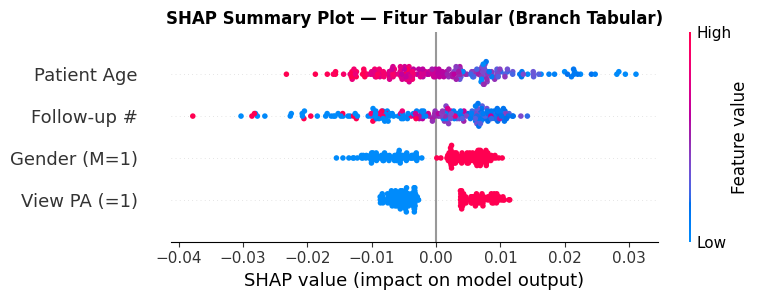

Disimpan → results/xai/shap_summary_dot.png


In [5]:
# Load jika sudah disimpan sebelumnya
# shap_values = np.load(XAI_DIR / "shap_values.npy")
# X_explain   = np.load(XAI_DIR / "shap_X_explain.npy")

plt.figure(figsize=(9, 5))
shap.summary_plot(
    shap_values, X_explain,
    feature_names=FEATURE_NAMES,
    show=False, plot_type="dot"
)
plt.title("SHAP Summary Plot — Fitur Tabular (Branch Tabular)", fontweight="bold")
plt.tight_layout()
plt.savefig(XAI_DIR / "shap_summary_dot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan → results/xai/shap_summary_dot.png")

## 5. SHAP Bar Plot (Mean |SHAP|)

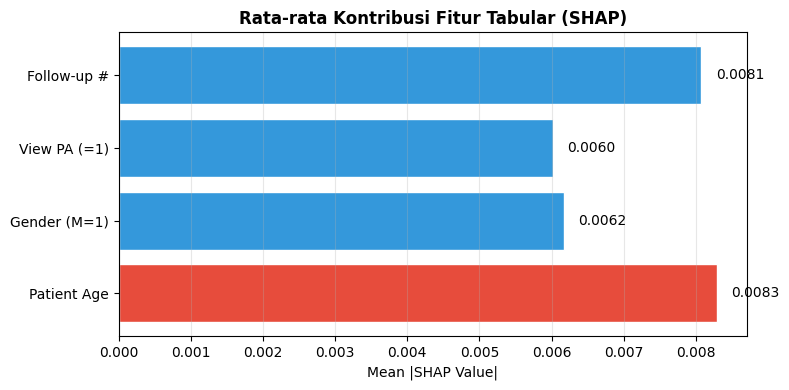

Kontribusi per fitur:
  Patient Age           : 0.0083  ████████████████████
  Follow-up #           : 0.0081  ███████████████████
  Gender (M=1)          : 0.0062  ██████████████
  View PA (=1)          : 0.0060  ██████████████

Mean |SHAP| total : 0.0071


In [6]:
mean_shap = np.mean(np.abs(shap_values), axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#e74c3c" if v == mean_shap.max() else "#3498db" for v in mean_shap]
bars = ax.barh(FEATURE_NAMES, mean_shap, color=colors, edgecolor="white")
for bar, val in zip(bars, mean_shap):
    ax.text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=10)
ax.set_xlabel("Mean |SHAP Value|")
ax.set_title("Rata-rata Kontribusi Fitur Tabular (SHAP)", fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(XAI_DIR / "shap_bar_mean.png", dpi=150, bbox_inches="tight")
plt.show()

print("Kontribusi per fitur:")
for name, val in sorted(zip(FEATURE_NAMES, mean_shap), key=lambda x: -x[1]):
    bar_str = "█" * int(val / mean_shap.max() * 20)
    print(f"  {name:<22}: {val:.4f}  {bar_str}")

print(f"\nMean |SHAP| total : {mean_shap.mean():.4f}")

# Simpan ke tabel
pd.DataFrame({"Feature": FEATURE_NAMES, "Mean_SHAP": mean_shap}).to_csv(
    TABLES_DIR / "shap_mean_importance.csv", index=False
)

## 6. SHAP Waterfall Plot (Per Pasien)

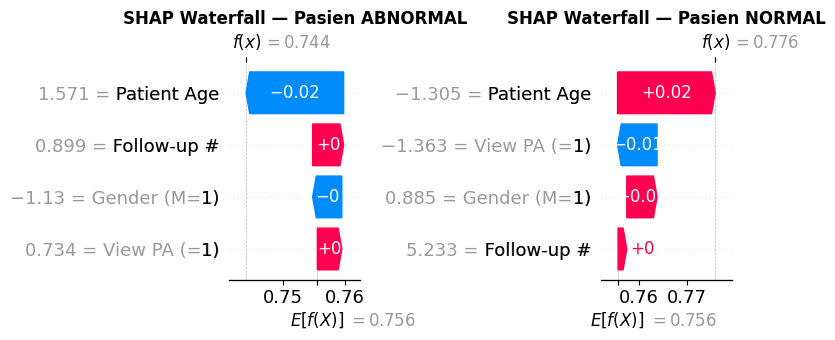

Disimpan → results/xai/shap_waterfall.png


In [7]:
# Pilih 1 pasien abnormal dan 1 pasien normal untuk waterfall
labels_explain = y_test[explain_idx]
idx_abnormal   = np.where(labels_explain == 1)[0][0]
idx_normal     = np.where(labels_explain == 0)[0][0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, idx, title in [
    (axes[0], idx_abnormal, "Pasien ABNORMAL"),
    (axes[1], idx_normal,   "Pasien NORMAL"),
]:
    plt.sca(ax)
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_explain[idx],
            feature_names=FEATURE_NAMES,
        ),
        show=False
    )
    ax.set_title(f"SHAP Waterfall — {title}", fontweight="bold")

plt.tight_layout()
plt.savefig(XAI_DIR / "shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan → results/xai/shap_waterfall.png")

---
# Part B: Grad-CAM — Branch Gambar

Menggunakan gradient dari output prediksi terhadap activation map layer Conv2D terakhir (denseblock4) untuk menghasilkan heatmap area yang paling berpengaruh.

## 7. Implementasi Grad-CAM

In [8]:
from torchvision import transforms
from PIL import Image

# Transform untuk inference (sama dengan test transform)
infer_transform = transforms.Compose([
    transforms.Resize((cfg.data.image_size, cfg.data.image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def make_gradcam_heatmap(
    img_tensor: torch.Tensor,
    tab_tensor: torch.Tensor,
    model: nn.Module,
    target_layer: nn.Module,
) -> np.ndarray:
    """
    Hitung Grad-CAM heatmap dari layer target.
    img_tensor: (1, 3, H, W), tab_tensor: (1, n_tab)
    """
    model.eval()
    activations, gradients = [], []

    # Hook untuk tangkap activation & gradient
    def forward_hook(module, inp, out):
        activations.append(out.detach())

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0].detach())

    h_fwd = target_layer.register_forward_hook(forward_hook)
    h_bwd = target_layer.register_full_backward_hook(backward_hook)

    # Forward pass
    logit = model(image=img_tensor, tabular=tab_tensor).squeeze()
    # Backward pass terhadap logit (class target = abnormal)
    model.zero_grad()
    logit.backward()

    h_fwd.remove()
    h_bwd.remove()

    # Hitung heatmap: global average pooling gradients → timbang activations
    grads  = gradients[0].squeeze(0)      # (C, H, W)
    acts   = activations[0].squeeze(0)    # (C, H, W)
    weights = grads.mean(dim=(1, 2))       # (C,)

    heatmap = (weights[:, None, None] * acts).sum(dim=0)  # (H, W)
    heatmap = torch.relu(heatmap).cpu().numpy()

    # Normalisasi 0–1
    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()
    return heatmap


def overlay_heatmap(
    img_path: str,
    heatmap: np.ndarray,
    alpha: float = 0.45,
):
    """Overlay Grad-CAM heatmap ke gambar asli."""
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (cfg.data.image_size, cfg.data.image_size))

    heatmap_resized = cv2.resize(heatmap, (cfg.data.image_size, cfg.data.image_size))
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(img, 1 - alpha, heatmap_colored, alpha, 0)
    return img, heatmap_resized, overlay


# Layer target: denseblock4 di ImageBranch
target_layer = model.image_branch.features.denseblock4
print(f"Target layer untuk Grad-CAM: {target_layer.__class__.__name__}")
print("(denseblock4 = layer Conv terakhir DenseNet-121)")

Target layer untuk Grad-CAM: _DenseBlock
(denseblock4 = layer Conv terakhir DenseNet-121)


## 8. Grad-CAM — Pasien Normal vs Abnormal

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


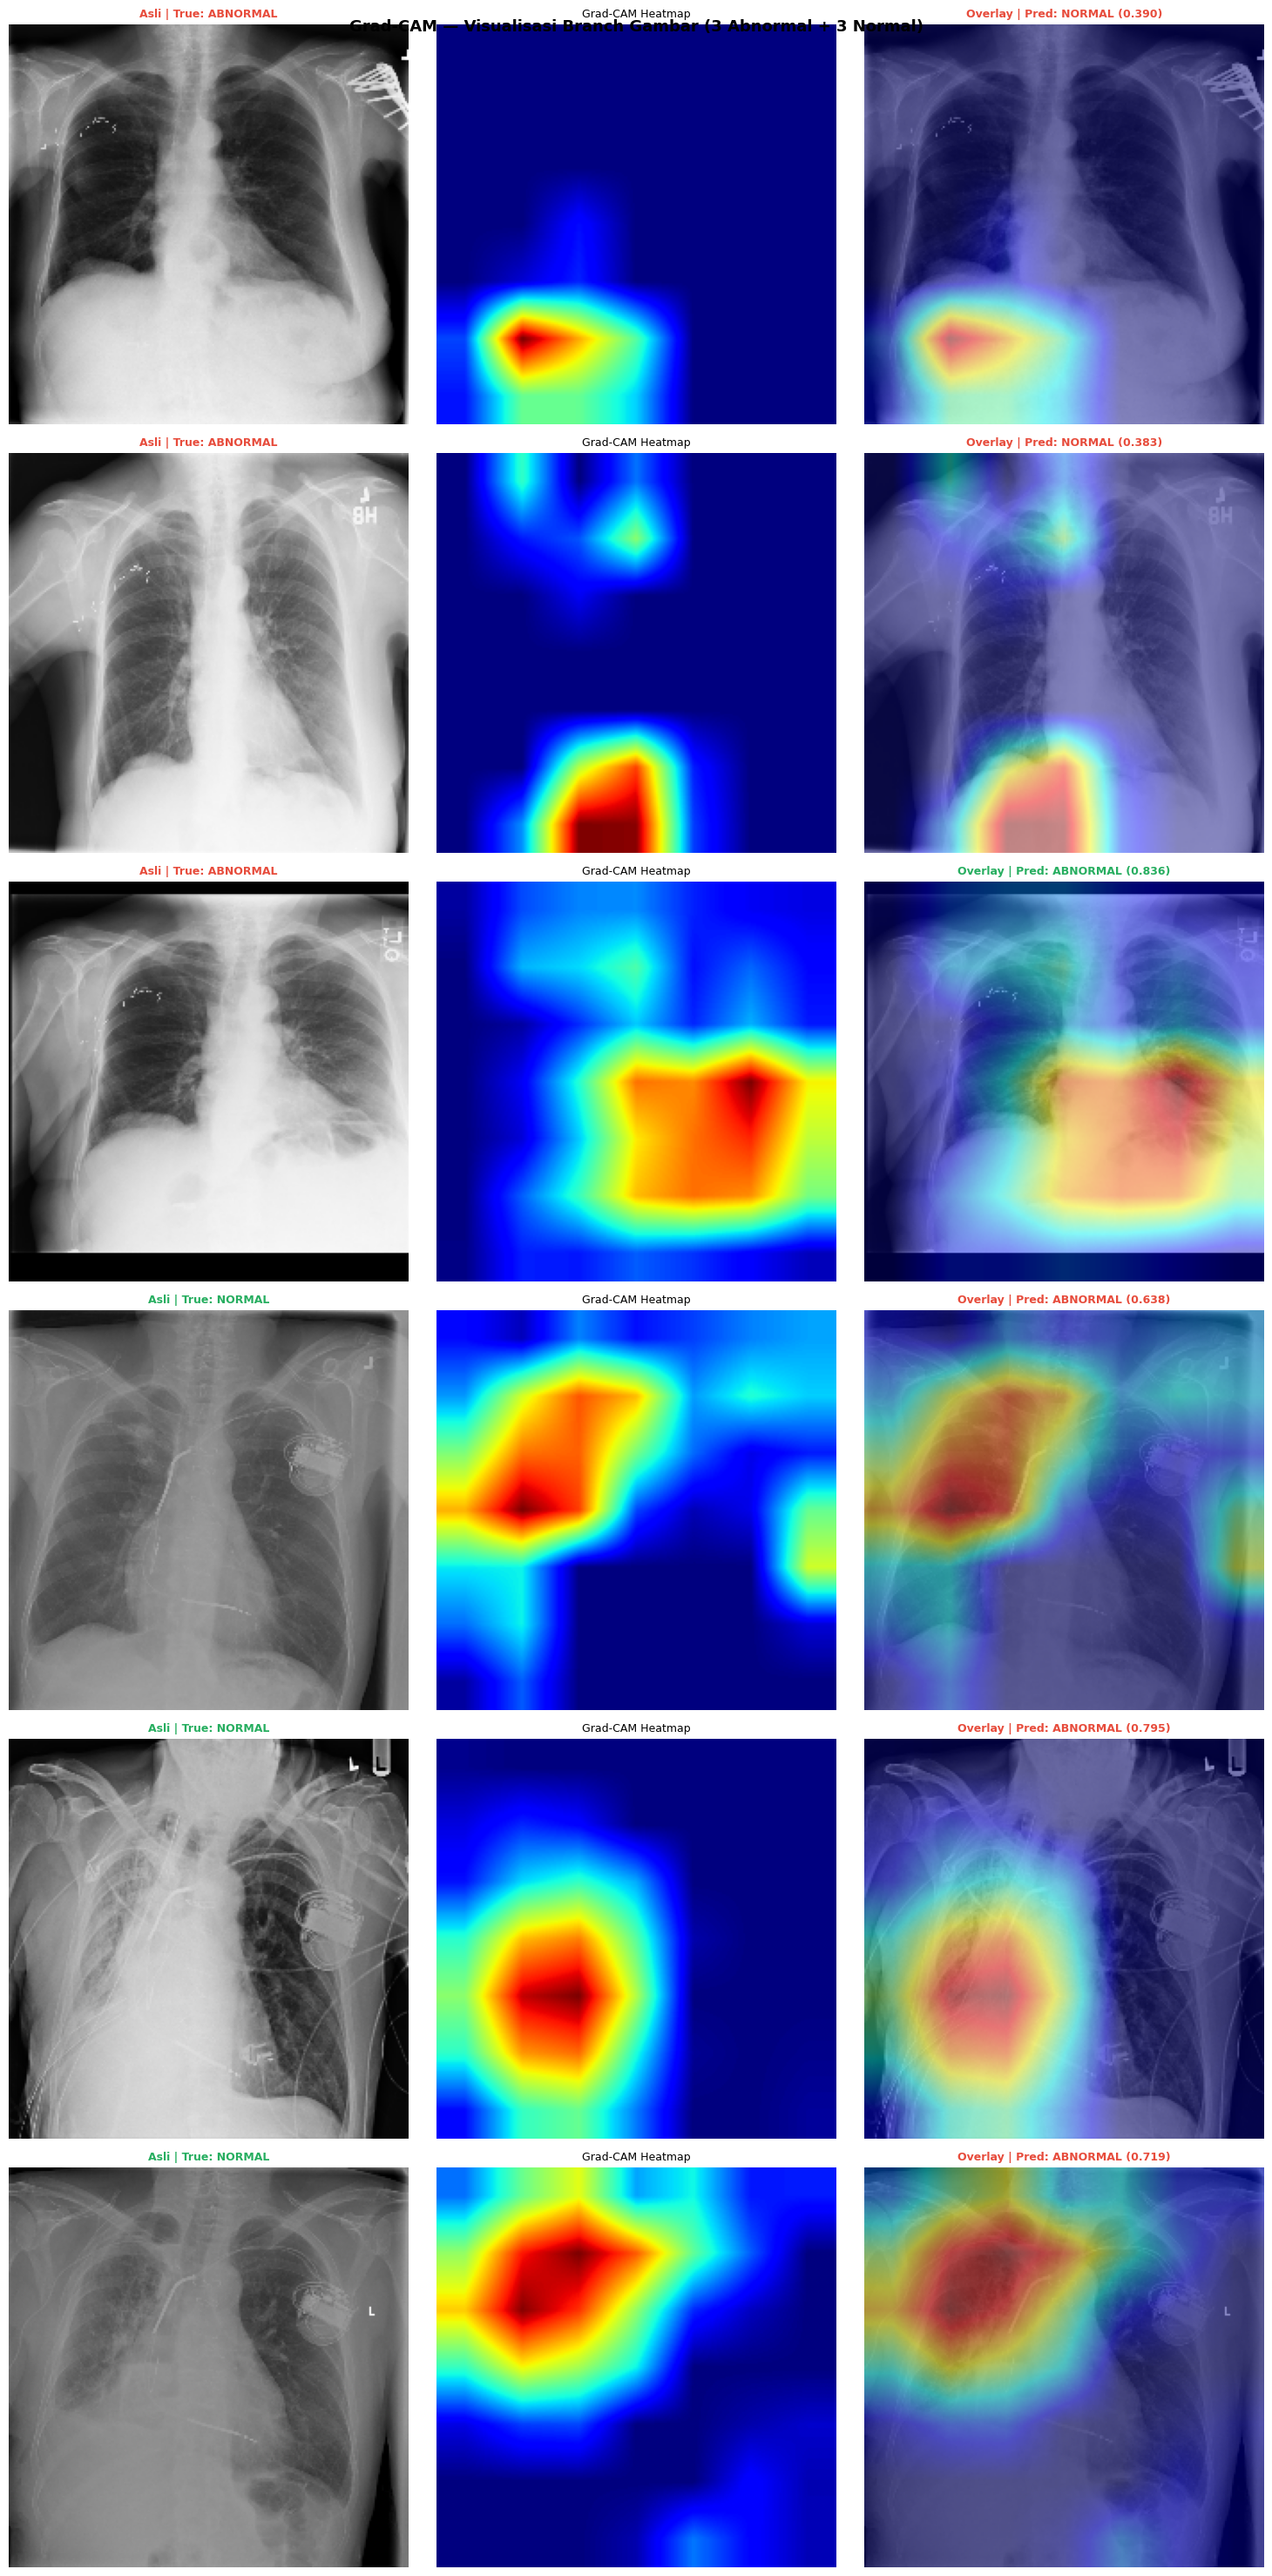

Disimpan → results/xai/gradcam_grid.png


In [9]:
# Pilih sampel dari test set
idx_abn = np.where(y_test == 1)[0][:3]   # 3 pasien abnormal
idx_nor = np.where(y_test == 0)[0][:3]   # 3 pasien normal
selected_idx = np.concatenate([idx_abn, idx_nor])

fig, axes = plt.subplots(len(selected_idx), 3, figsize=(15, len(selected_idx) * 5))

for row, idx in enumerate(selected_idx):
    fname    = img_names[idx]
    img_path = image_index[fname]
    true_lbl = "ABNORMAL" if y_test[idx] == 1 else "NORMAL"

    # Prepare tensor
    pil_img    = Image.open(img_path).convert("RGB")
    img_tensor = infer_transform(pil_img).unsqueeze(0).to(DEVICE)
    tab_tensor = torch.tensor(X_tab_test[idx:idx+1], dtype=torch.float32).to(DEVICE)

    # Prediksi
    with torch.no_grad():
        prob = torch.sigmoid(model(image=img_tensor, tabular=tab_tensor)).item()
    pred_lbl = "ABNORMAL" if prob >= 0.5 else "NORMAL"

    # Grad-CAM
    heatmap = make_gradcam_heatmap(img_tensor, tab_tensor, model, target_layer)
    orig, heat_resized, overlay = overlay_heatmap(img_path, heatmap)

    color = "#e74c3c" if true_lbl == "ABNORMAL" else "#27ae60"
    axes[row, 0].imshow(orig, cmap="gray")
    axes[row, 0].set_title(f"Asli | True: {true_lbl}", color=color, fontweight="bold", fontsize=9)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(heat_resized, cmap="jet")
    axes[row, 1].set_title("Grad-CAM Heatmap", fontsize=9)
    axes[row, 1].axis("off")

    pred_color = "#27ae60" if pred_lbl == true_lbl else "#e74c3c"
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(f"Overlay | Pred: {pred_lbl} ({prob:.3f})",
                           color=pred_color, fontweight="bold", fontsize=9)
    axes[row, 2].axis("off")

plt.suptitle("Grad-CAM — Visualisasi Branch Gambar (3 Abnormal + 3 Normal)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(XAI_DIR / "gradcam_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan → results/xai/gradcam_grid.png")

---
# Part C: Ringkasan Kontribusi Dua Modalitas

## 9. Dashboard Dual XAI (1 Pasien)

  0%|          | 0/1 [00:00<?, ?it/s]

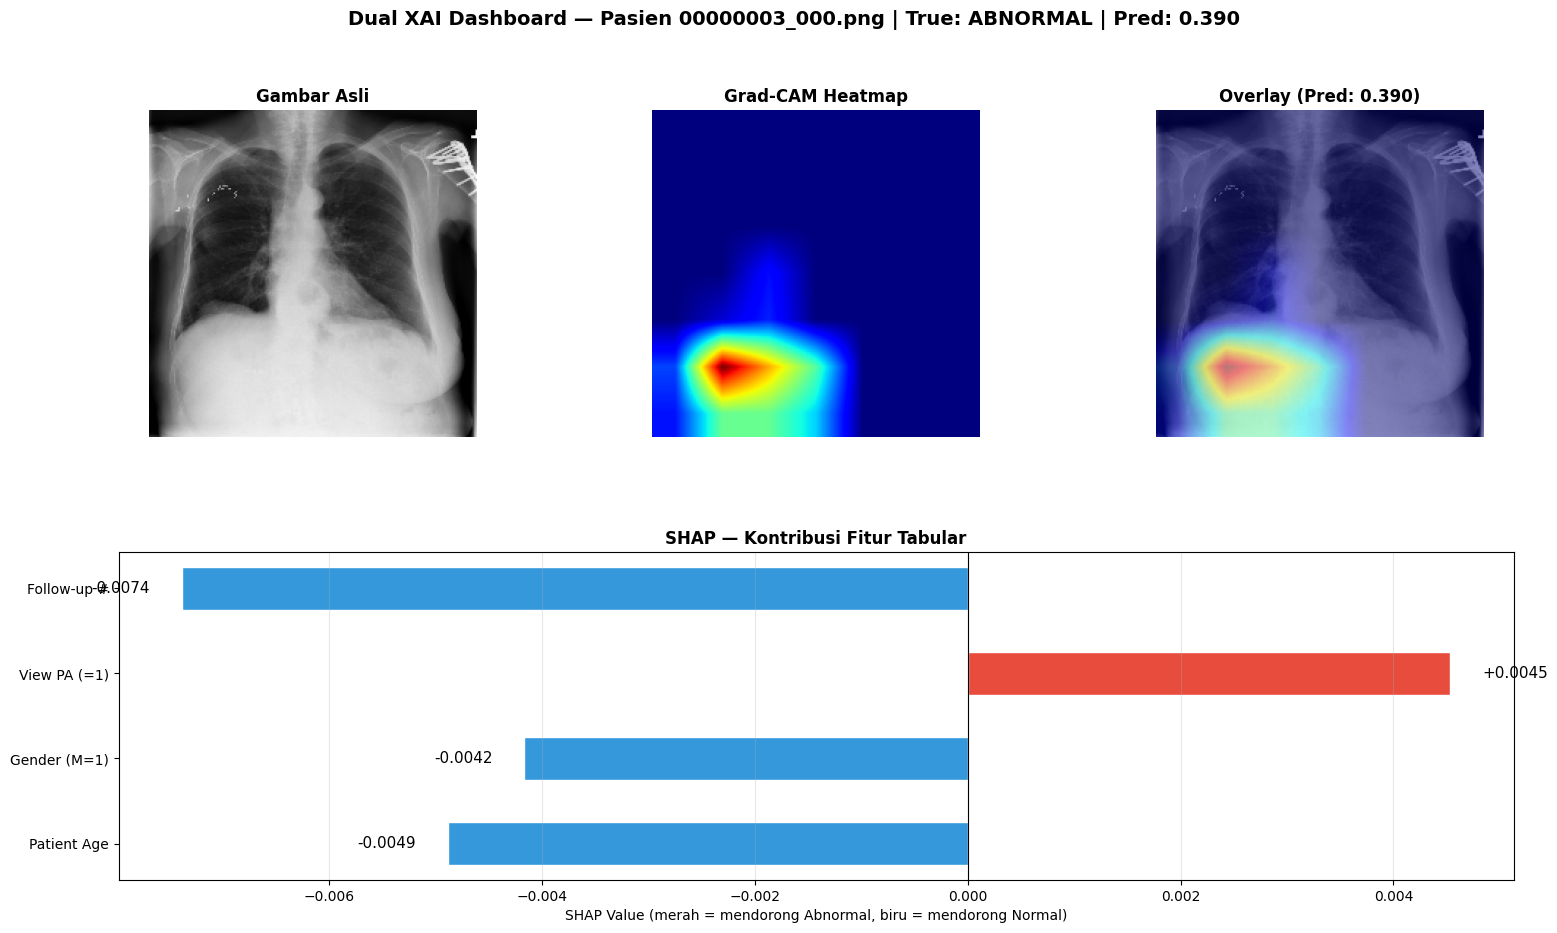

Disimpan → results/xai/dual_xai_dashboard.png


In [10]:
# Pilih satu pasien abnormal yang menarik untuk visualisasi lengkap
DEMO_IDX = np.where(y_test == 1)[0][0]

fname    = img_names[DEMO_IDX]
img_path = image_index[fname]
pil_img  = Image.open(img_path).convert("RGB")
img_tensor = infer_transform(pil_img).unsqueeze(0).to(DEVICE)
tab_tensor = torch.tensor(X_tab_test[DEMO_IDX:DEMO_IDX+1], dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    prob = torch.sigmoid(model(image=img_tensor, tabular=tab_tensor)).item()

heatmap = make_gradcam_heatmap(img_tensor, tab_tensor, model, target_layer)
orig, heat_resized, overlay = overlay_heatmap(img_path, heatmap)

# SHAP untuk pasien ini
shap_single = explainer.shap_values(X_tab_test[DEMO_IDX:DEMO_IDX+1], nsamples=256)[0]

# ── Layout 2×3 ──
fig = plt.figure(figsize=(18, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

# Row 1: Gambar X-ray
ax1 = fig.add_subplot(gs[0, 0]); ax2 = fig.add_subplot(gs[0, 1]); ax3 = fig.add_subplot(gs[0, 2])
ax1.imshow(orig, cmap="gray");          ax1.set_title("Gambar Asli", fontweight="bold"); ax1.axis("off")
ax2.imshow(heat_resized, cmap="jet");   ax2.set_title("Grad-CAM Heatmap", fontweight="bold"); ax2.axis("off")
ax3.imshow(overlay);                    ax3.set_title(f"Overlay (Pred: {prob:.3f})", fontweight="bold"); ax3.axis("off")

# Row 2: SHAP tabular
ax4 = fig.add_subplot(gs[1, :])
colors_shap = ["#e74c3c" if v > 0 else "#3498db" for v in shap_single]
bars = ax4.barh(FEATURE_NAMES, shap_single, color=colors_shap, edgecolor="white", height=0.5)
for bar, val in zip(bars, shap_single):
    ax4.text(val + (0.0003 if val >= 0 else -0.0003),
             bar.get_y() + bar.get_height()/2,
             f"{val:+.4f}", va="center", fontsize=11,
             ha="left" if val >= 0 else "right")
ax4.axvline(0, color="black", linewidth=0.8)
ax4.set_xlabel("SHAP Value (merah = mendorong Abnormal, biru = mendorong Normal)", fontsize=10)
ax4.set_title("SHAP — Kontribusi Fitur Tabular", fontweight="bold")
ax4.grid(axis="x", alpha=0.3)

fig.suptitle(
    f"Dual XAI Dashboard — Pasien {fname} | True: ABNORMAL | Pred: {prob:.3f}",
    fontsize=14, fontweight="bold"
)
plt.savefig(XAI_DIR / "dual_xai_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan → results/xai/dual_xai_dashboard.png")

## 10. Interpretasi Kuantitatif & Ringkasan Bab 4

In [11]:
mean_shap = np.mean(np.abs(shap_values), axis=0)
total_shap = mean_shap.mean()

print("=" * 60)
print("RINGKASAN KONTRIBUSI DUA MODALITAS")
print("=" * 60)

print("\n[Branch Tabular — SHAP KernelExplainer]")
for name, val in sorted(zip(FEATURE_NAMES, mean_shap), key=lambda x: -x[1]):
    bar = "█" * max(1, int(val / mean_shap.max() * 25))
    print(f"  {name:<22}: {val:.4f}  {bar}")
print(f"  {'Mean |SHAP| total':<22}: {total_shap:.4f}")

print("\n[Branch Gambar — Grad-CAM]")
print("  Lihat: results/xai/gradcam_grid.png")
print("  Area merah = kontribusi tinggi pada prediksi")

print("\n[Interpretasi untuk Bab 4]")
dominant = FEATURE_NAMES[np.argmax(mean_shap)]
if total_shap > 0.02:
    print(f"  ✓ Fitur tabular berkontribusi terukur, terutama '{dominant}'")
    print("    Hal ini menunjukkan informasi demografis pasien")
    print("    memiliki pengaruh yang dapat diukur pada prediksi model.")
elif total_shap > 0.005:
    print(f"  ✓ Fitur tabular berkontribusi moderat (mean |SHAP| = {total_shap:.4f})")
    print("    Kontribusi lebih rendah dari gambar X-ray,")
    print("    mengindikasikan dominasi fitur visual dalam prediksi biner.")
else:
    print(f"  ✓ Kontribusi tabular sangat kecil (mean |SHAP| = {total_shap:.4f})")
    print("    Fitur demografis tidak signifikan secara prediktif.")
    print("    Temuan ini valid secara empiris dan dapat dijadikan")
    print("    saran untuk menggunakan fitur klinis yang lebih kaya.")

print("\n" + "=" * 60)
print("ARTEFAK XAI TERSIMPAN DI: results/xai/")
print("  shap_values.npy        — raw SHAP values")
print("  shap_summary_dot.png   — summary plot (Bab 4)")
print("  shap_bar_mean.png      — bar plot importance")
print("  shap_waterfall.png     — waterfall per pasien")
print("  gradcam_grid.png       — Grad-CAM 6 sampel")
print("  dual_xai_dashboard.png — dashboard dual XAI")
print("=" * 60)

RINGKASAN KONTRIBUSI DUA MODALITAS

[Branch Tabular — SHAP KernelExplainer]
  Patient Age           : 0.0083  █████████████████████████
  Follow-up #           : 0.0081  ████████████████████████
  Gender (M=1)          : 0.0062  ██████████████████
  View PA (=1)          : 0.0060  ██████████████████
  Mean |SHAP| total     : 0.0071

[Branch Gambar — Grad-CAM]
  Lihat: results/xai/gradcam_grid.png
  Area merah = kontribusi tinggi pada prediksi

[Interpretasi untuk Bab 4]
  ✓ Fitur tabular berkontribusi moderat (mean |SHAP| = 0.0071)
    Kontribusi lebih rendah dari gambar X-ray,
    mengindikasikan dominasi fitur visual dalam prediksi biner.

ARTEFAK XAI TERSIMPAN DI: results/xai/
  shap_values.npy        — raw SHAP values
  shap_summary_dot.png   — summary plot (Bab 4)
  shap_bar_mean.png      — bar plot importance
  shap_waterfall.png     — waterfall per pasien
  gradcam_grid.png       — Grad-CAM 6 sampel
  dual_xai_dashboard.png — dashboard dual XAI
